In [1]:
#!/usr/bin/env python3
"""
Simple Topology Test: 3 Versions for CartPole

This script tests 3 different approaches to using topology networks with PPO on CartPole:

1. Version A: Minimal Task Adapters (Universal approach)
   - Uses input/output adapters for future multi-task compatibility
   - CartPole: 4→6 input, 2→3 output adapters

2. Version B: IO Padding/Truncation (Universal approach)
   - Uses padding/truncation instead of adapters
   - CartPole: pad 4→6 input, truncate 3→2 output

3. Version C: Single Task Direct (Simple approach)
   - No adapters, no padding, direct CartPole dimensions (4→2)
   - Minimal complexity, just topology network as MLP replacement

4. Version D: Standard PyTorch MLP (as Baseline Comparison)

All versions use fully connected topology and should achieve similar performance to standard MLP.
"""

'\nSimple Topology Test: 3 Versions for CartPole\n\nThis script tests 3 different approaches to using topology networks with PPO on CartPole:\n\n1. Version A: Minimal Task Adapters (Universal approach)\n   - Uses input/output adapters for future multi-task compatibility\n   - CartPole: 4→6 input, 2→3 output adapters\n\n2. Version B: IO Padding/Truncation (Universal approach)\n   - Uses padding/truncation instead of adapters\n   - CartPole: pad 4→6 input, truncate 3→2 output\n\n3. Version C: Single Task Direct (Simple approach)\n   - No adapters, no padding, direct CartPole dimensions (4→2)\n   - Minimal complexity, just topology network as MLP replacement\n\n4. Version D: Standard PyTorch MLP (as Baseline Comparison)\n\nAll versions use fully connected topology and should achieve similar performance to standard MLP.\n'

In [2]:

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.policies import ActorCriticPolicy
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import sys
import os

# Add src to path
sys.path.append('src')

from src.topologies.fully_connected import FullyConnectedTopology
from src.networks.ffn import FeedForwardNetwork


In [3]:

class TrainingCallback(BaseCallback):
    """Callback to track training metrics."""
    
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self.current_episode_reward = 0
        self.current_episode_length = 0
        
    def _on_step(self) -> bool:
        # Track episode rewards
        if len(self.training_env.buf_rews) > 0:
            self.current_episode_reward += self.training_env.buf_rews[0]
            self.current_episode_length += 1
            
            if self.training_env.buf_dones[0]:
                self.episode_rewards.append(self.current_episode_reward)
                self.episode_lengths.append(self.current_episode_length)
                self.current_episode_reward = 0
                self.current_episode_length = 0
        
        return True

class StandardMLPPolicy(ActorCriticPolicy):
    """Standard MLP policy for comparison."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Simple architecture matching the standard MLP
        self.shared_net = nn.Sequential(
            nn.Linear(self.features_dim, 64),  # 4 → 64
            nn.ReLU(),
            nn.Linear(64, 64),                 # 64 → 64
            nn.ReLU(),
        )
        
        # Actor head (policy)
        self.action_net = nn.Sequential(
            nn.Linear(64, 32),                 # 64 → 32
            nn.ReLU(),
            nn.Linear(32, action_space.n)      # 32 → 2
        )
        
        # Critic head (value)
        self.value_net = nn.Sequential(
            nn.Linear(64, 32),                 # 64 → 32
            nn.ReLU(),
            nn.Linear(32, 1)                   # 32 → 1
        )
    
    def forward_actor(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.action_net(shared_features)
    
    def forward_critic(self, obs):
        features = self.extract_features(obs)
        shared_features = self.shared_net(features)
        return self.value_net(shared_features)

# ============================================================================
# VERSION A: Minimal Task Adapters (Universal approach)
# ============================================================================

class MinimalAdapter(nn.Module):
    """Minimal adapter with configurable complexity."""
    
    def __init__(self, input_dim: int, output_dim: int, adapter_type: str = 'linear'):
        super().__init__()
        self.adapter_type = adapter_type
        
        if adapter_type == 'linear':
            # Simple linear projection
            self.projection = nn.Linear(input_dim, output_dim)
        elif adapter_type == 'tiny_mlp':
            # Tiny MLP with minimal hidden layer
            self.projection = nn.Sequential(
                nn.Linear(input_dim, 8),
                nn.ReLU(),
                nn.Linear(8, output_dim)
            )
        else:
            raise ValueError(f"Unknown adapter type: {adapter_type}")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.projection(x)

class VersionA_AdapterPolicy(ActorCriticPolicy):
    """Version A: Universal topology with minimal task adapters."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.task_input_dim = observation_space.shape[0]  # 4 for CartPole
        self.task_output_dim = action_space.n  # 2 for CartPole
        
        # Universal dimensions (fixed across all tasks)
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        
        print(f"[Version A] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version A] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create minimal input adapter (4 → 6)
        self.input_adapter = MinimalAdapter(
            self.task_input_dim, 
            self.universal_input_dim, 
            adapter_type='linear'
        )
        
        # Create topology network
        self.topology_network = self._create_topology_network()
        
        # Create minimal output adapter (3 → 2)
        self.output_adapter = MinimalAdapter(
            self.universal_output_dim, 
            self.task_output_dim, 
            adapter_type='linear'
        )
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the topology network with universal dimensions."""
        # Total nodes: input + hidden + output
        total_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        # Create fully connected topology
        topology = FullyConnectedTopology(
            size=total_size,
            num_layers=1,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        # Generate graph
        graph = topology.generate()
        
        # Define input/output nodes
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        # Create network
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        return FeedForwardNetwork(
            topology=graph,
            input_nodes=input_nodes,
            output_nodes=output_nodes,
            network_params=network_params
        )
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Input adapter: project to universal input space
        universal_input = self.input_adapter(features)  # (batch_size, 6)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)  # (batch_size, 3)
        
        # Output adapter: project to task output space
        task_output = self.output_adapter(universal_output)  # (batch_size, 2)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Input adapter: project to universal input space
        universal_input = self.input_adapter(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Output adapter: project to task output space
        task_output = self.output_adapter(universal_output)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# VERSION B: IO Padding/Truncation (Universal approach)
# ============================================================================

class VersionB_PaddingPolicy(ActorCriticPolicy):
    """Version B: Universal topology with padding/truncation."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Task-specific dimensions
        self.task_input_dim = observation_space.shape[0]  # 4 for CartPole
        self.task_output_dim = action_space.n  # 2 for CartPole
        
        # Universal dimensions (fixed across all tasks)
        self.universal_input_dim = 6
        self.universal_output_dim = 3
        self.hidden_size = 64
        
        print(f"[Version B] Task: {self.task_input_dim}→{self.task_output_dim}")
        print(f"[Version B] Universal: {self.universal_input_dim}→{self.universal_output_dim}")
        
        # Create topology network
        self.topology_network = self._create_topology_network()
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.task_output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the topology network with universal dimensions."""
        # Total nodes: input + hidden + output
        total_size = self.universal_input_dim + self.hidden_size + self.universal_output_dim
        
        # Create fully connected topology
        topology = FullyConnectedTopology(
            size=total_size,
            num_layers=1,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        # Generate graph
        graph = topology.generate()
        
        # Define input/output nodes
        input_nodes = list(range(self.universal_input_dim))
        output_nodes = list(range(self.universal_input_dim + self.hidden_size, 
                                 self.universal_input_dim + self.hidden_size + self.universal_output_dim))
        
        # Create network
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        return FeedForwardNetwork(
            topology=graph,
            input_nodes=input_nodes,
            output_nodes=output_nodes,
            network_params=network_params
        )
    
    def _pad_input(self, x: torch.Tensor) -> torch.Tensor:
        """Pad input from task dimension to universal dimension."""
        batch_size = x.shape[0]
        if x.shape[1] < self.universal_input_dim:
            # Pad with zeros
            padding = torch.zeros(batch_size, self.universal_input_dim - x.shape[1], device=x.device)
            return torch.cat([x, padding], dim=1)
        else:
            # Truncate if needed
            return x[:, :self.universal_input_dim]
    
    def _truncate_output(self, x: torch.Tensor) -> torch.Tensor:
        """Truncate output from universal dimension to task dimension."""
        return x[:, :self.task_output_dim]
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Pad input: 4 → 6
        universal_input = self._pad_input(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)  # (batch_size, 3)
        
        # Truncate output: 3 → 2
        task_output = self._truncate_output(universal_output)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Pad input: 4 → 6
        universal_input = self._pad_input(features)
        
        # Convert to dictionary format for topology network
        input_dict = {i: universal_input[:, i] for i in range(self.universal_input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.universal_output_dim):
            output_node_idx = self.universal_input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        universal_output = torch.stack(output_values, dim=1)
        
        # Truncate output: 3 → 2
        task_output = self._truncate_output(universal_output)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# VERSION C: Single Task Direct (Simple approach)
# ============================================================================

class VersionC_DirectPolicy(ActorCriticPolicy):
    """Version C: Direct topology with CartPole dimensions (4→2)."""
    
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        super().__init__(observation_space, action_space, lr_schedule, *args, **kwargs)
        
        # Direct CartPole dimensions
        self.input_dim = observation_space.shape[0]  # 4 for CartPole
        self.output_dim = action_space.n  # 2 for CartPole
        self.hidden_size = 64
        
        print(f"[Version C] Direct: {self.input_dim}→{self.output_dim}")
        
        # Create topology network
        self.topology_network = self._create_topology_network()
        
        # Actor head (policy)
        self.actor_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_space.n)
        )
        
        # Critic head (value)
        self.critic_head = nn.Sequential(
            nn.Linear(self.output_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def _create_topology_network(self):
        """Create the topology network with direct CartPole dimensions."""
        # Total nodes: input + hidden + output
        total_size = self.input_dim + self.hidden_size + self.output_dim
        
        # Create fully connected topology
        topology = FullyConnectedTopology(
            size=total_size,
            num_layers=1,
            inter_layer_prob=1.0,
            intra_layer_prob=1.0,
            seed=42
        )
        
        # Generate graph
        graph = topology.generate()
        
        # Define input/output nodes
        input_nodes = list(range(self.input_dim))
        output_nodes = list(range(self.input_dim + self.hidden_size, 
                                 self.input_dim + self.hidden_size + self.output_dim))
        
        # Create network
        network_params = {
            'learning_rate': 0.001,
            'activation': 'tanh'
        }
        
        return FeedForwardNetwork(
            topology=graph,
            input_nodes=input_nodes,
            output_nodes=output_nodes,
            network_params=network_params
        )
    
    def forward_actor(self, obs):
        """Forward pass for actor (policy)."""
        features = self.extract_features(obs)
        
        # Convert to dictionary format for topology network
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        task_output = torch.stack(output_values, dim=1)  # (batch_size, 2)
        
        # Actor head
        return self.actor_head(task_output)
    
    def forward_critic(self, obs):
        """Forward pass for critic (value)."""
        features = self.extract_features(obs)
        
        # Convert to dictionary format for topology network
        input_dict = {i: features[:, i] for i in range(self.input_dim)}
        
        # Forward through topology network
        topology_output = self.topology_network.forward(input_dict)
        
        # Convert topology output to tensor
        output_values = []
        batch_size = features.shape[0]
        for i in range(self.output_dim):
            output_node_idx = self.input_dim + self.hidden_size + i
            val = topology_output.get(output_node_idx, 0.0)
            if not torch.is_tensor(val):
                val = torch.tensor(val, dtype=torch.float32, device=features.device)
                if val.dim() == 0:
                    val = val.repeat(batch_size)
            output_values.append(val)
        task_output = torch.stack(output_values, dim=1)
        
        # Critic head
        return self.critic_head(task_output)

# ============================================================================
# TESTING FUNCTIONS
# ============================================================================

def test_policy(policy_class, policy_name, total_timesteps=50000):
    """Test a specific policy."""
    print(f"\n=== Testing {policy_name} ===")
    
    def make_env():
        return gym.make('CartPole-v1')
    
    env = DummyVecEnv([make_env])
    env = VecNormalize(env, norm_obs=True, norm_reward=False)
    
    model = PPO(
        policy_class,
        env,
        learning_rate=2e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=4,
        gamma=0.99,
        clip_range=0.15,
        ent_coef=0.02,
        verbose=0
    )
    
    callback = TrainingCallback()
    model.learn(total_timesteps=total_timesteps, callback=callback, progress_bar=True)
    
    # Test performance
    test_rewards = []
    for i in range(10):
        obs = env.reset()
        total_reward = 0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            total_reward += reward[0]
            done = done[0]
        test_rewards.append(total_reward)
    
    avg_reward = np.mean(test_rewards)
    print(f"{policy_name} - Average test reward: {avg_reward:.2f}")
    print(f"{policy_name} - All test rewards: {test_rewards}")
    
    return {
        'type': policy_name,
        'avg_reward': avg_reward,
        'test_rewards': test_rewards,
        'episode_rewards': callback.episode_rewards
    }

In [4]:
# Test all policies
results = []

# Test Standard MLP (baseline)
results.append(test_policy(StandardMLPPolicy, "Standard MLP"))


=== Testing Standard MLP ===


Output()

Standard MLP - Average test reward: 500.00
Standard MLP - All test rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


In [5]:
# Test Version A: Minimal Task Adapters
results.append(test_policy(VersionA_AdapterPolicy, "Version A: Adapters"))

Output()


=== Testing Version A: Adapters ===
[Version A] Task: 4→2
[Version A] Universal: 6→3


Version A: Adapters - Average test reward: 228.10
Version A: Adapters - All test rewards: [230.0, 249.0, 227.0, 204.0, 220.0, 220.0, 229.0, 223.0, 235.0, 244.0]


In [6]:
# Test Version B: IO Padding/Truncation
results.append(test_policy(VersionB_PaddingPolicy, "Version B: Padding"))

Output()


=== Testing Version B: Padding ===
[Version B] Task: 4→2
[Version B] Universal: 6→3


Version B: Padding - Average test reward: 500.00
Version B: Padding - All test rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


In [7]:
# Test Version C: Single Task Direct
results.append(test_policy(VersionC_DirectPolicy, "Version C: Direct"))


=== Testing Version C: Direct ===
[Version C] Direct: 4→2


Output()

Version C: Direct - Average test reward: 500.00
Version C: Direct - All test rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


In [8]:
for result in results:
    print(f"{result['type']:25} | Avg Reward: {result['avg_reward']:6.2f} | "
            f"Min: {min(result['test_rewards']):4.0f} | Max: {max(result['test_rewards']):4.0f}")

Standard MLP              | Avg Reward: 500.00 | Min:  500 | Max:  500
Version A: Adapters       | Avg Reward: 228.10 | Min:  204 | Max:  249
Version B: Padding        | Avg Reward: 500.00 | Min:  500 | Max:  500
Version C: Direct         | Avg Reward: 500.00 | Min:  500 | Max:  500


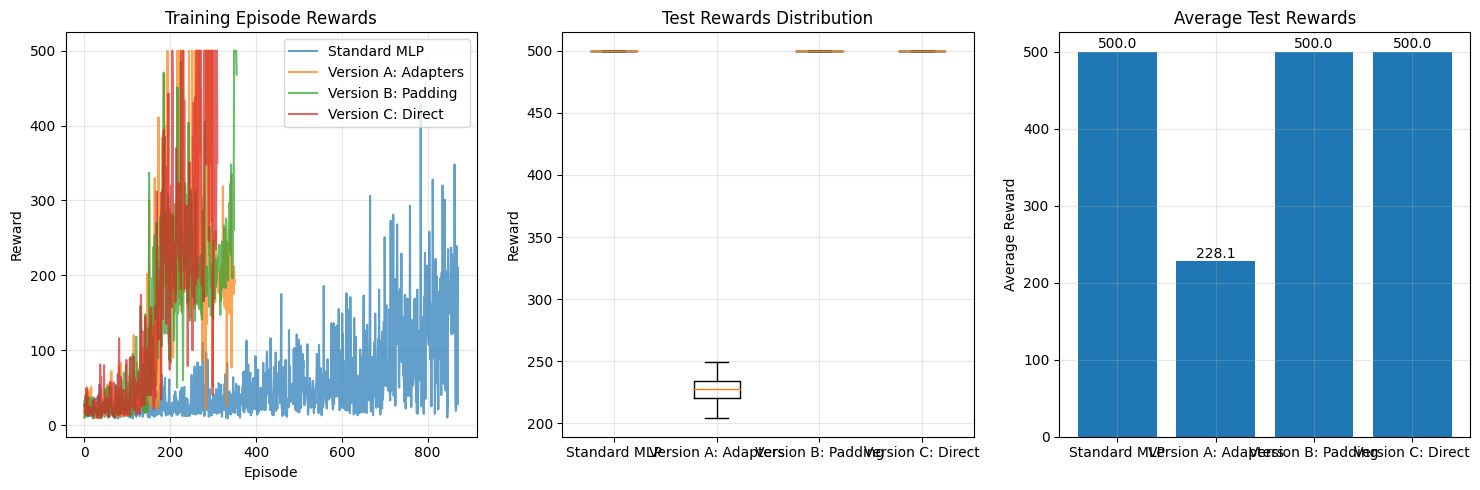

In [9]:
"""Plot training curves for all policies."""
plt.figure(figsize=(15, 5))

# Plot episode rewards
plt.subplot(1, 3, 1)
for result in results:
    if result['episode_rewards']:
        plt.plot(result['episode_rewards'], label=result['type'], alpha=0.7)
plt.title('Training Episode Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot test rewards distribution
plt.subplot(1, 3, 2)
test_rewards_data = [result['test_rewards'] for result in results]
plt.boxplot(test_rewards_data, labels=[result['type'] for result in results])
plt.title('Test Rewards Distribution')
plt.ylabel('Reward')
plt.grid(True, alpha=0.3)

# Plot average test rewards
plt.subplot(1, 3, 3)
avg_rewards = [result['avg_reward'] for result in results]
policy_names = [result['type'] for result in results]
bars = plt.bar(policy_names, avg_rewards)
plt.title('Average Test Rewards')
plt.ylabel('Average Reward')

# Add value labels on bars
for bar, reward in zip(bars, avg_rewards):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{reward:.1f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()